In [2]:
#Monthly Job Postings for Top Data Jobs in the US
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [27]:
df_PH_DA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Philippines')].copy()
#explode job_skills column
df_PH_DA = df_PH_DA.explode('job_skills')
#remove salary_year_avg NA's
df_PH_DA = df_PH_DA.dropna(subset='salary_year_avg')
df_PH_DA

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
115695,Data Analyst,Data Analyst (Procurement/Logistics),"Tarlac City, Tarlac, Philippines",via Ai-Jobs.net,Full-time,False,Philippines,2023-08-25 08:14:55,False,False,Philippines,year,111175.0,NaN,Pilmico Foods Corporation,excel,"{'analyst_tools': ['excel', 'tableau']}"
115695,Data Analyst,Data Analyst (Procurement/Logistics),"Tarlac City, Tarlac, Philippines",via Ai-Jobs.net,Full-time,False,Philippines,2023-08-25 08:14:55,False,False,Philippines,year,111175.0,NaN,Pilmico Foods Corporation,tableau,"{'analyst_tools': ['excel', 'tableau']}"
147342,Data Analyst,Data Management Assistant ( Stay-in Set-up),"Tarlac City, Tarlac, Philippines",via Ai-Jobs.net,Full-time,False,Philippines,2023-02-07 08:16:41,False,False,Philippines,year,50400.0,NaN,Pilmico Foods Corporation,None,None
166142,Data Analyst,"Data Analyst, Customer Experience","Manila, Metro Manila, Philippines",via Ai-Jobs.net,Full-time,False,Philippines,2023-03-03 15:19:36,True,False,Philippines,year,111175.0,NaN,Dialpad,sql,"{'other': ['flow'], 'programming': ['sql']}"
166142,Data Analyst,"Data Analyst, Customer Experience","Manila, Metro Manila, Philippines",via Ai-Jobs.net,Full-time,False,Philippines,2023-03-03 15:19:36,True,False,Philippines,year,111175.0,NaN,Dialpad,flow,"{'other': ['flow'], 'programming': ['sql']}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777328,Data Analyst,Data Product Manager,"Makati, Metro Manila, Philippines",via Ai-Jobs.net,Full-time,False,Philippines,2023-07-04 05:15:58,False,False,Philippines,year,64800.0,NaN,Angkas,sql,"{'analyst_tools': ['tableau', 'looker', 'power..."
777328,Data Analyst,Data Product Manager,"Makati, Metro Manila, Philippines",via Ai-Jobs.net,Full-time,False,Philippines,2023-07-04 05:15:58,False,False,Philippines,year,64800.0,NaN,Angkas,tableau,"{'analyst_tools': ['tableau', 'looker', 'power..."
777328,Data Analyst,Data Product Manager,"Makati, Metro Manila, Philippines",via Ai-Jobs.net,Full-time,False,Philippines,2023-07-04 05:15:58,False,False,Philippines,year,64800.0,NaN,Angkas,looker,"{'analyst_tools': ['tableau', 'looker', 'power..."
777328,Data Analyst,Data Product Manager,"Makati, Metro Manila, Philippines",via Ai-Jobs.net,Full-time,False,Philippines,2023-07-04 05:15:58,False,False,Philippines,year,64800.0,NaN,Angkas,power bi,"{'analyst_tools': ['tableau', 'looker', 'power..."


In [40]:
df_PH_DA_group = df_PH_DA.groupby('job_skills')['salary_year_avg'].agg(['median', 'count'])
df_PH_DA_group

df_PH_DA_top_pay = df_PH_DA_group.sort_values(by='median', ascending=False).head(10)

df_PH_DA_skills = df_PH_DA_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)
df_PH_DA_skills

,median,count
job_skills,,
sql,100500.0,13
tableau,100500.0,7
python,100500.0,7
r,100500.0,6
powerpoint,100500.0,3
jira,100189.5,2
snowflake,98500.0,3
excel,89204.0,9
power bi,69900.0,5


In [63]:
import seaborn as sns

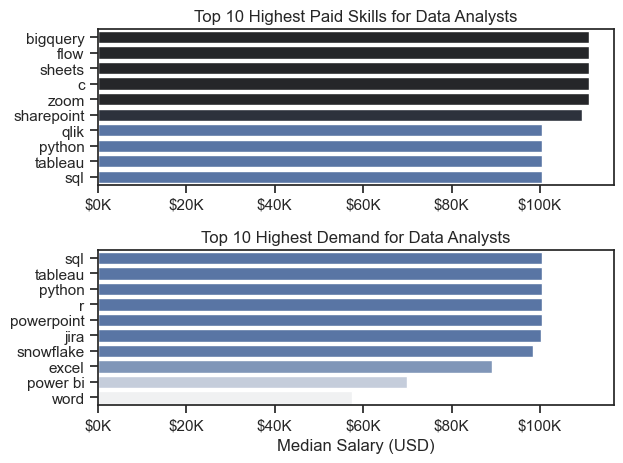

In [98]:
#plotting
sns.set_theme(style='ticks')
fig, ax = plt.subplots(2,1)

sns.barplot(data=df_PH_DA_top_pay, x='median', y='job_skills', hue='median', palette='dark:b_r', ax=ax[0], legend=False)
#df_PH_DA_top_pay.plot(y='median', kind='barh', ax=ax[0], legend=False)
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))

sns.barplot(data=df_PH_DA_skills, x='median', y='job_skills', hue='median', palette='light:b', ax=ax[1], legend=False)
#df_PH_DA_skills.plot(y='median', kind='barh', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Highest Demand for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
ax[1].set_xlim(ax[0].get_xlim())
plt.tight_layout()